In [1]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importing Dataset
df = pd.read_csv('https://raw.githubusercontent.com/MohammedAyanSyed/projects/refs/heads/main/End-to-End%20Apps/AI-Traffic-Intelligence-Platform/data/processed/cleaned_dataset.csv',parse_dates=['time'])

In [3]:
# Dataset Info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234552 entries, 0 to 234551
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   region_index               234552 non-null  int64         
 1   city                       234552 non-null  object        
 2   region_label               234552 non-null  object        
 3   time                       234552 non-null  datetime64[ns]
 4   speed_kmh                  234552 non-null  float64       
 5   free_flow_speed_kmh        234552 non-null  float64       
 6   congestion_level           234552 non-null  float64       
 7   travel_time_per_10_km_min  234552 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(2)
memory usage: 14.3+ MB


,region_index,time,speed_kmh,free_flow_speed_kmh,congestion_level,travel_time_per_10_km_min
count,234552.000000,234552,234552.000000,234552.000000,234552.000000,234552.000000
mean,5.777938,2025-04-01 11:31:15.560216832,28.287362,36.773442,35.243303,23.784087
min,0.000000,2025-01-01 00:00:00,7.300000,17.700000,0.000000,6.700000
25%,2.000000,2025-02-15 05:00:00,20.600000,29.400000,13.800000,17.500000
50%,5.000000,2025-04-01 12:00:00,26.400000,35.700000,32.000000,22.600000
75%,10.000000,2025-05-16 18:00:00,34.000000,42.700000,52.700000,29.000000
max,15.000000,2025-06-30 23:00:00,88.800000,90.500000,210.200000,81.100000
std,4.524296,NaN,10.308847,10.406334,24.573460,8.127278


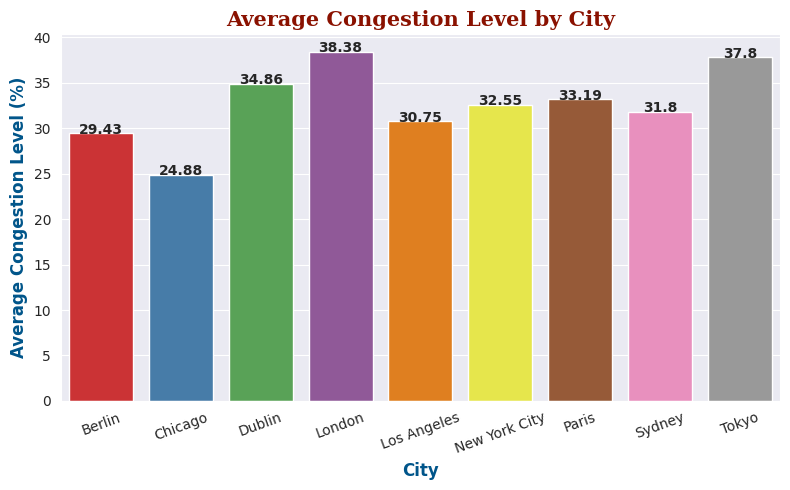

In [4]:
# Group By
avg_congest = df.groupby('city')['congestion_level'].mean().reset_index()

# Figure Size
plt.figure(figsize=(8,5))

# Page Style
sns.set_style('darkgrid')

# Barplot
ax = sns.barplot(x='city',y='congestion_level',data=avg_congest,hue='city',palette='Set1')

# Annotation
for i in ax.patches:
    length = i.get_height()
    if length > 0:
        plt.text(i.get_x()+i.get_width()/2,length+(np.max(avg_congest['congestion_level'])*0.01),round(length,2),ha='center',va='center',
                fontweight='bold')

# Styling Title and Labels
plt.title('Average Congestion Level by City',fontweight='bold',fontsize=15,fontfamily='Serif',color='#8A1100')
plt.xlabel('City',fontweight='bold',fontsize=12,color='#00558A')
plt.ylabel('Average Congestion Level (%)',fontweight='bold',fontsize=12,color='#00558A')
plt.xticks(rotation=20)

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# London and Tokyo shows the highest average congestion levels.
# Chicago demonsrates comparatively smoother traffic flow.
# Variation across cities which makes city an important predictive feature for regression modeling.

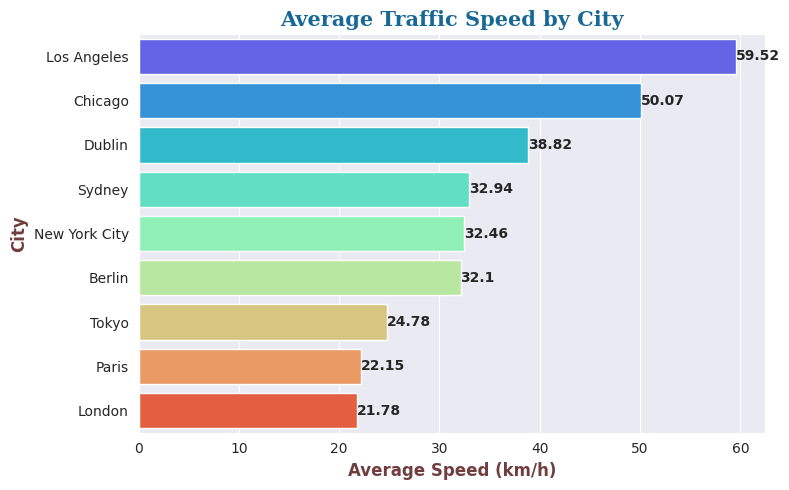

In [5]:
# Sorting
avg_speed = df.groupby('city')['speed_kmh'].mean().reset_index()
sort_avg_speed = sorted(zip(avg_speed['city'],avg_speed['speed_kmh']),key=lambda x : x[1],reverse=True)
mc,mv = zip(*sort_avg_speed)

# Figure Size
plt.figure(figsize=(8,5))

# Page Theme
sns.set_style('darkgrid')

# Barplot
ax = sns.barplot(x=mv,y=mc,hue=mc,palette='rainbow')

# Annotation
for i in ax.patches:
    width = i.get_width()
    if width > 0:
        plt.text(width,i.get_y()+i.get_height()/2,round(width,2),ha='left',va='center',fontweight='bold')

# Styling Labels and Title
plt.title('Average Traffic Speed by City',fontweight='bold',fontsize=15,fontfamily='Serif',color='#186896')
plt.xlabel('Average Speed (km/h)',fontweight='bold',fontsize=12,color='#703E3E')
plt.ylabel('City',fontweight='bold',fontsize=12,color='#703E3E')

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# Los Angeles and Chicago show higher average speed
# Speed appears inversely related to congestion
# Making important feature for regression model

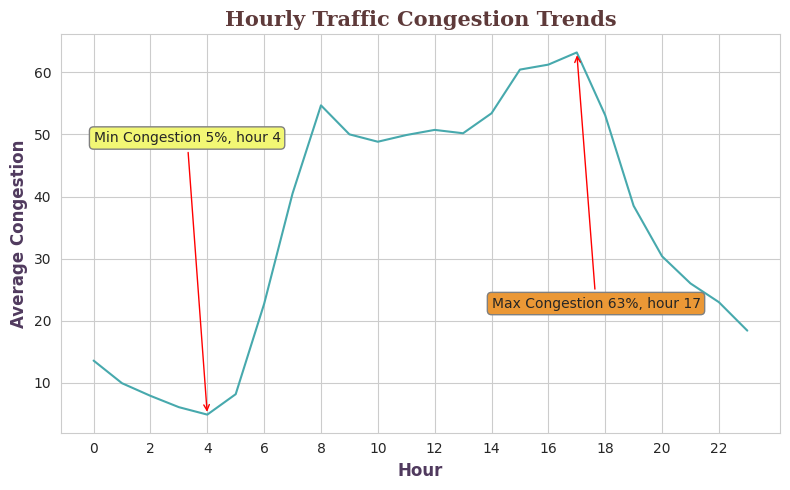

In [6]:
# Group By
busy_hour = df.groupby(df['time'].dt.hour)['congestion_level'].mean().reset_index()

# Figure Size
plt.figure(figsize=(8,5))

# Page Theme
sns.set_style('whitegrid')

# Lineplot
sns.lineplot(x='time',y='congestion_level',data=busy_hour,color='#47A9AD',markers='o')

# Annotation
maxi = busy_hour['congestion_level'].idxmax()
maxi_value = busy_hour.loc[maxi,'congestion_level']
mini = busy_hour['congestion_level'].idxmin()
mini_value = busy_hour.loc[mini,'congestion_level']
plt.annotate(xy=(maxi,maxi_value),xytext=(maxi-3,maxi_value*0.35),text=f'Max Congestion {round(maxi_value)}%, hour {maxi}',
            arrowprops=dict(arrowstyle='->',color='r'),bbox=dict(boxstyle='round',facecolor='#EB9836',edgecolor='grey'))
plt.annotate(xy=(mini,mini_value),xytext=(mini-4,mini_value*10),text=f'Min Congestion {round(mini_value)}%, hour {mini}',
            arrowprops=dict(arrowstyle='->',color='r'),bbox=dict(boxstyle='round',facecolor='#F2F774',edgecolor='grey'))

# Styling Labels and Title
plt.title('Hourly Traffic Congestion Trends',fontweight='bold',fontsize=15,fontfamily='Serif',color='#5E3A3A')
plt.xlabel('Hour',fontweight='bold',fontsize=12,color='#503A5E')
plt.ylabel('Average Congestion',fontweight='bold',fontsize=12,color='#503A5E')
plt.xticks(range(0,24,2))

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# Traffic congestion peaks during evening rush hours
# Congestion remains lowest durinf late-night and early morning hours.

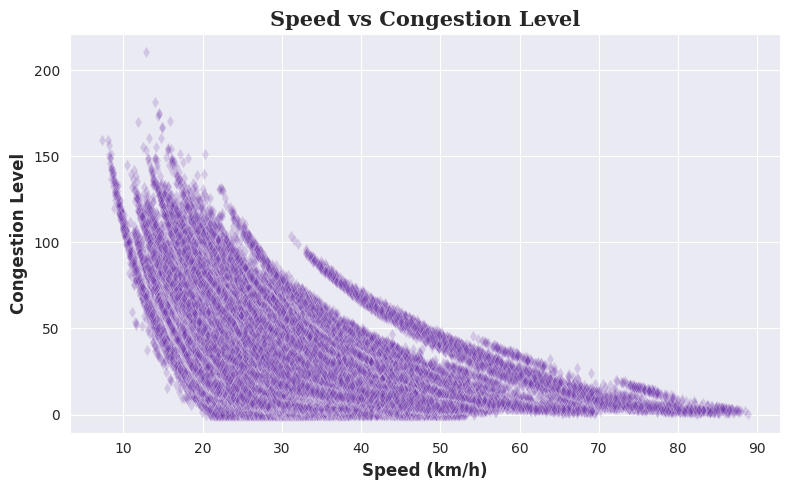

In [7]:
# Figure Size
plt.figure(figsize=(8,5))

# Page Theme
sns.set_style('darkgrid')

# Scatterplot
sns.scatterplot(x='speed_kmh',y='congestion_level',data=df,alpha=0.2,marker='d',color='#6E37AB')

# Styling Title and Labels
plt.title('Speed vs Congestion Level',fontweight='bold',fontsize=15,fontfamily='Serif')
plt.xlabel('Speed (km/h)',fontweight='bold',fontsize=12)
plt.ylabel('Congestion Level',fontweight='bold',fontsize=12)

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# Congestion level decreases as the vechicle speed increases
# High Congestion periods are generally associated with lower traffic speeds

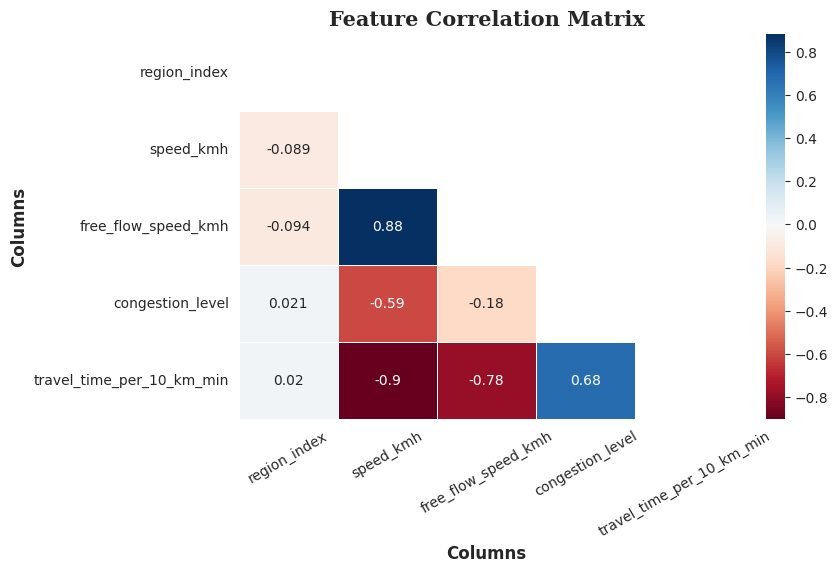

In [9]:
# Figure Size
plt.figure(figsize=(8,5))

# Selecting Columns
num_cols = df.select_dtypes(include=[int,float]).columns.to_list()
correlation = df[num_cols].corr()

# Heatmap
mask = np.triu(np.ones_like(correlation,dtype=bool))
sns.heatmap(correlation,mask=mask,annot=True,cmap='RdBu',linewidths=0.5)

# Styling Title and Labels
plt.title('Feature Correlation Matrix',fontweight='bold',fontsize=15,fontfamily='Serif')
plt.xlabel('Columns',fontweight='bold',fontsize=12)
plt.ylabel('Columns',fontweight='bold',fontsize=12)
plt.xticks(rotation=30)

# Page Layout
plt.show()

# Insights:
# Higher congestion leads to longer travel times
# Faster traffic generally corresponds to lower congestion
# Speed and travel time appear to be strong predictive features

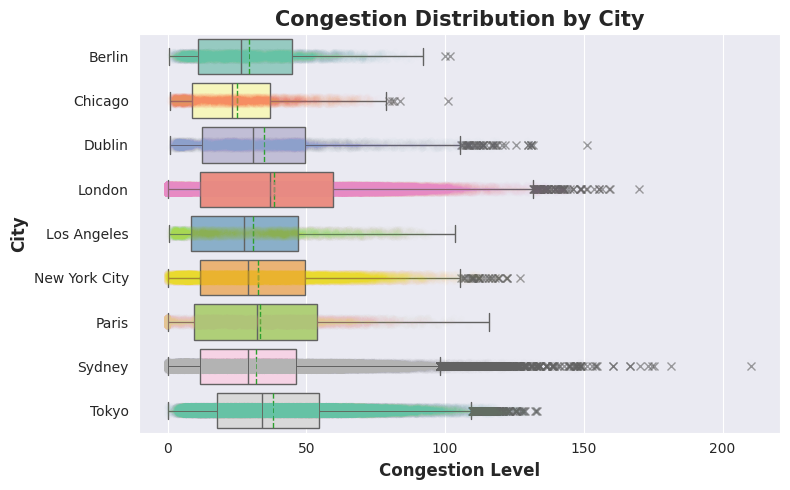

In [10]:
# Figure Size
plt.figure(figsize=(8,5))

# Page Theme
sns.set_style('darkgrid')

# Box plot + Stripplot
sns.boxplot(x='congestion_level',y='city',data=df,hue='city',palette='Set3',showmeans=True,meanline=True,
            flierprops=dict(marker='x',alpha=0.6))
sns.stripplot(x='congestion_level',y='city',data=df,hue='city',palette='Set2',alpha=0.01)

# Styling title and labels
plt.title('Congestion Distribution by City',fontweight='bold',fontsize=15)
plt.xlabel('Congestion Level',fontweight='bold',fontsize=12)
plt.ylabel('City',fontweight='bold',fontsize=12)

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# Some cities shows wider congestion range indicating highly variable traffic conditions
# Other cities show tigher distributions, suggesting more predictable traffic patterns

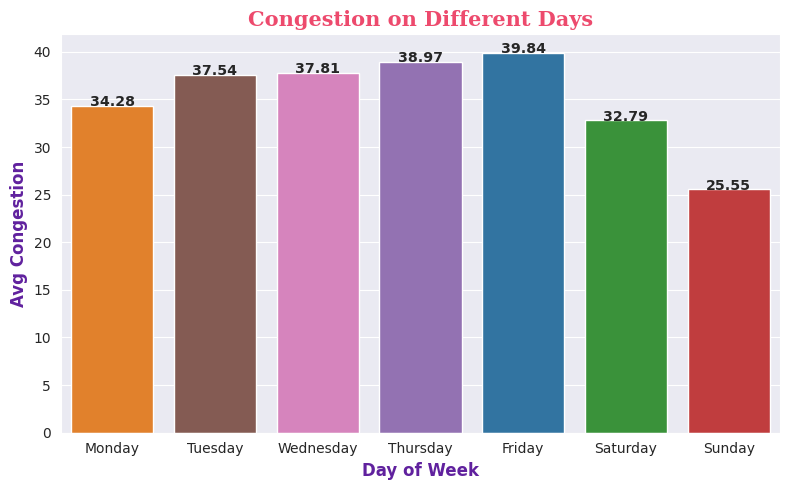

In [11]:
# Week
week = df.groupby(df['time'].dt.day_name())['congestion_level'].mean().reset_index()

# Figure Size
plt.figure(figsize=(8,5))

# Page Theme
sns.set_style('darkgrid')

# Barplot
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
ax = sns.barplot(x='time',y='congestion_level',data=week,hue='time',palette='tab10',order=order)

# Annotation
for i in ax.patches:
    height = i.get_height()
    if height > 0:
        plt.text(i.get_x()+i.get_width()/2,height+0.4,round(height,2),fontweight='bold',fontsize=10.2,ha='center',va='center')

# Styling title and labels
plt.title('Congestion on Different Days',fontweight='bold',fontsize=15,fontfamily='Serif',color='#ED4A6D')
plt.xlabel('Day of Week',fontweight='bold',fontsize=12,color='#60219E')
plt.ylabel('Avg Congestion',fontweight='bold',fontsize=12,color='#60219E')

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# Traffic congestion is highest on Friday, indicating increased end of week travel demand
# weekend congestion is lower than weekday congestion
# weekly traffic patterns suggest that day-of-week is an important feature for congestion for congestion prediction

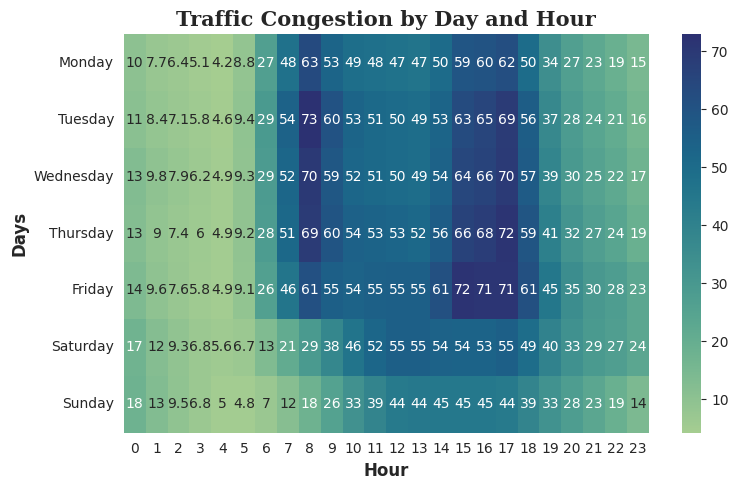

In [12]:
# Week Avg
week_avg = pd.pivot_table(data=df,index=df['time'].dt.day_name(),columns=df['time'].dt.hour,values='congestion_level',aggfunc='mean')
arrange_week = week_avg.reindex(order)

# Figure Size
plt.figure(figsize=(8,5))

# Heatmap

sns.heatmap(arrange_week,cmap='crest',annot=True)

# Styling Title and Labels
plt.title('Traffic Congestion by Day and Hour',fontweight='bold',fontsize=15,fontfamily='Serif')
plt.xlabel('Hour',fontweight='bold',fontsize=12)
plt.ylabel('Days',fontweight='bold',fontsize=12)

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# weekdays mornings and evenings the highest congestion levels
# Friday evening experiences the most severe traffic conditions
# weekend traffic remains comparatively lower throughout the day

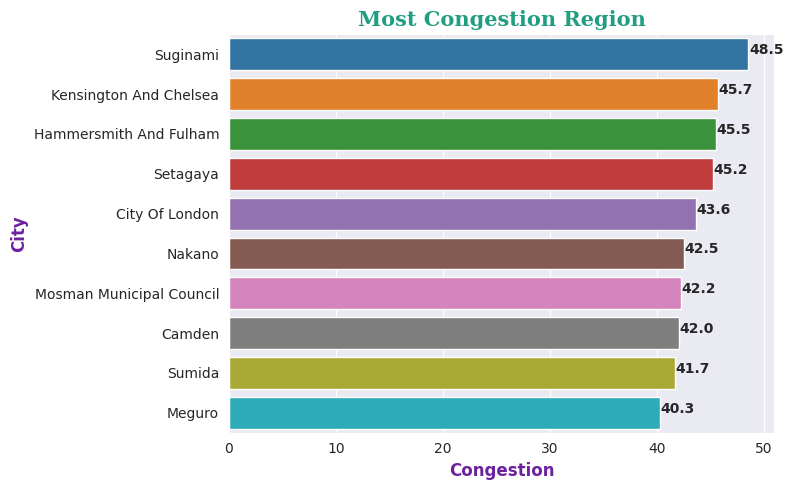

In [13]:
# City Congestion
high_congestion = df.groupby('region_label')['congestion_level'].mean().reset_index()
sorted_data = sorted(zip(high_congestion['region_label'],high_congestion['congestion_level']),key=lambda x : x[1],reverse=True)[:10]
sl,sv = zip(*sorted_data)

# Figure Size
plt.figure(figsize=(8,5))

# Page Theme
sns.set_style('darkgrid')

# Barplot
ax = sns.barplot(x=sv,y=sl,hue=sl,palette='tab10')

# Annotation
for i in ax.patches:
    width = i.get_width()
    if width > 0:
        plt.text(np.max(width)*1.001,i.get_y()+i.get_height()/2,round(width,1),fontweight='bold')

# Styling Titles and Labels
plt.title('Most Congestion Region',fontweight='bold',fontsize=15,color='#219E81',fontfamily='Serif')
plt.xlabel('Congestion',fontweight='bold',fontsize=12,color='#6C219E')
plt.ylabel('City',fontweight='bold',fontsize=12,color='#6C219E')

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# A small number of regions account for the highest congestion levels across all cities
# Region level congestion patterns suggest that it will be an important feature for model building

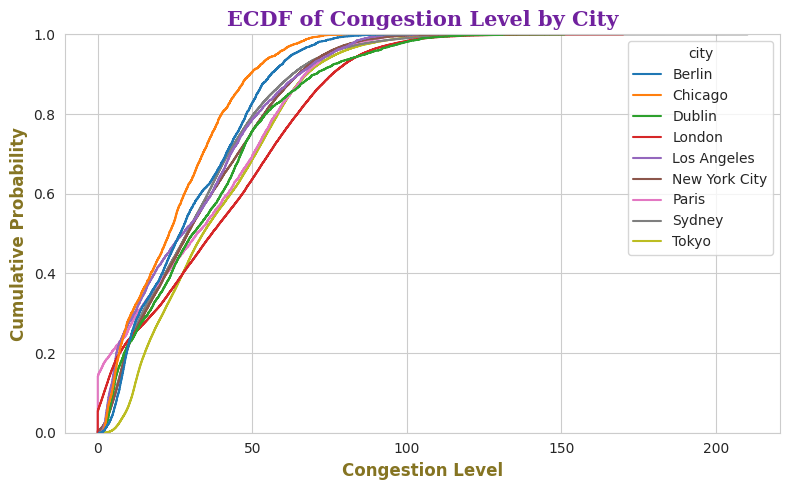

In [14]:
# Figure Size
plt.figure(figsize=(8,5))

# Page Theme
sns.set_style('whitegrid')

# Lineplot
sns.ecdfplot(x='congestion_level',hue='city',data=df)

# Styling Title and Labels
plt.title('ECDF of Congestion Level by City',fontweight='bold',fontsize=15,color='#70219E',fontfamily='Serif')
plt.xlabel('Congestion Level',fontweight='bold',fontsize=12,color='#857422')
plt.ylabel('Cumulative Probability',fontweight='bold',fontsize=12,color='#857422')

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# Congestion distribtuions vary significantly across cities
# Showing City-level congestion will be important feature as a predictive feature